In [4]:
import pandas as pd

# Load flights dataset
flights = pd.read_csv("dataset/flights.csv")

print(flights.shape)
flights.head()


(271888, 10)


,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,10/04/2019
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,10/10/2019


Select target + useful features 
Target variable

predict flight price:

y = price

Features we will START with 

Use:

flightType (categorical)

time (numeric)

distance (numeric)

agency (categorical)

Ignore :

travelCode, userCode (IDs)

from, to (text, later optional)

date (later optional)

In [5]:
# Select features and target
features = ["flightType", "time", "distance", "agency"]
target = "price"

X = flights[features]
y = flights[target]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (271888, 4)
y shape: (271888,)


,flightType,time,distance,agency
0,firstClass,1.76,676.53,FlyingDrops
1,firstClass,1.76,676.53,FlyingDrops
2,firstClass,1.66,637.56,CloudFy
3,firstClass,1.66,637.56,CloudFy
4,firstClass,2.16,830.86,CloudFy


In [6]:
#Encode categorical features (flightType, agency)

#One-Hot Encoding.


from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorical and numerical columns
categorical_cols = ["flightType", "agency"]
numerical_cols = ["time", "distance"]

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Apply transformation
X_encoded = preprocessor.fit_transform(X)

print("Encoded X shape:", X_encoded.shape)


Encoded X shape: (271888, 8)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (217510, 4) (217510,)
Test shape: (54378, 4) (54378,)


In [8]:
# One-hot encode categorical columns
X_encoded = pd.get_dummies(
    X,
    columns=["flightType", "agency"],
    drop_first=True
)

print("Encoded X shape:", X_encoded.shape)
X_encoded.head()


Encoded X shape: (271888, 6)


,time,distance,flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow
0,1.76,676.53,True,False,True,False
1,1.76,676.53,True,False,True,False
2,1.66,637.56,True,False,False,False
3,1.66,637.56,True,False,False,False
4,2.16,830.86,True,False,False,False


In [9]:
from sklearn.model_selection import train_test_split

# Convert boolean columns to int (True → 1, False → 0)
X_encoded = X_encoded.astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (217510, 6) (217510,)
Test shape: (54378, 6) (54378,)


In [10]:
#Train the Flight Price Model(random forest regressor)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)



MAE: 103.33997047707246
R2 Score: 0.8428745853639295


In [1]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("file:///C:/LABMENTIX/TEAM PROJECt/mlruns")
mlflow.set_experiment("Flight Price Prediction")


c:\Users\kbhuv\anaconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/01/19 06:21:51 INFO mlflow.tracking.fluent: Experiment with name 'Flight Price Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///C:/LABMENTIX/TEAM PROJECt/mlruns/252391284985332460', creation_time=1768783911333, experiment_id='252391284985332460', last_update_time=1768783911333, lifecycle_stage='active', name='Flight Price Prediction', tags={}>

In [11]:
with mlflow.start_run(run_name="flight_price_prediction_v1"):
    mlflow.log_param("model_type", "RandomForestRegressor")
    mlflow.log_param("n_estimators", rf_model.n_estimators)
    mlflow.log_param("max_depth", rf_model.max_depth)
    mlflow.log_param("random_state", 42)

    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("R2", r2)

    mlflow.sklearn.log_model(
        sk_model=rf_model,
        name="model"
    )


In [9]:
import joblib

joblib.dump(rf_model, "flight_price_prediction_model.pkl")
print("Flight price model saved successfully")


Flight price model saved successfully


In [10]:
#Feature Importance

#How much each feature contributes to reducing prediction error

#Higher value = more influence on flight price.

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from trained model
importances = rf_model.feature_importances_

# Feature names from encoded X
feature_names = X_encoded.columns

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feature_importance_df


,feature,importance
1,distance,0.553590
2,flightType_firstClass,0.351436
3,flightType_premium,0.091166
5,agency_Rainbow,0.002286
4,agency_FlyingDrops,0.001416
0,time,0.000106


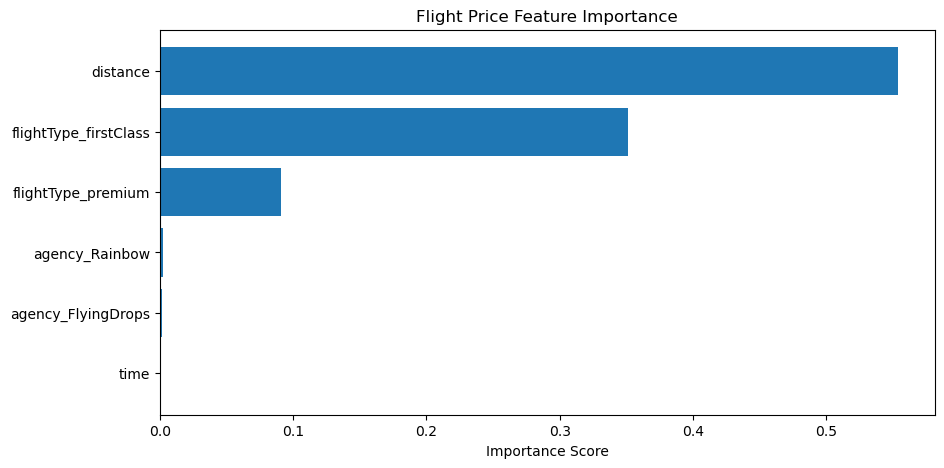

In [11]:
#visualize feature importance

plt.figure(figsize=(10, 5))
plt.barh(
    feature_importance_df["feature"],
    feature_importance_df["importance"]
)
plt.gca().invert_yaxis()
plt.title("Flight Price Feature Importance")
plt.xlabel("Importance Score")
plt.show()


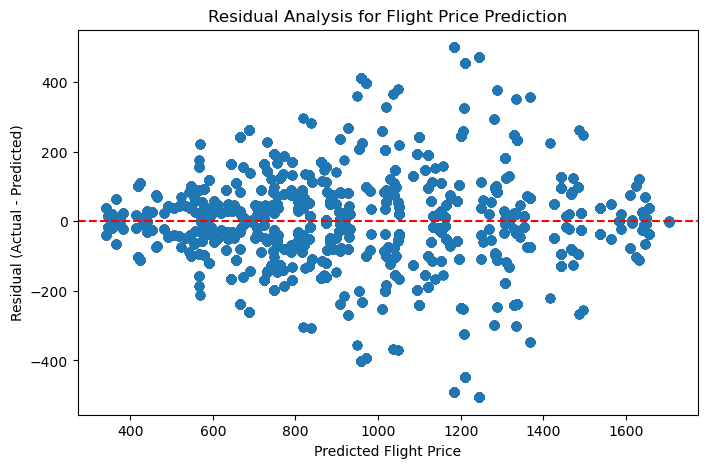

In [12]:
#Residual Error Analysis

import matplotlib.pyplot as plt

# Residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(8,5))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Flight Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Analysis for Flight Price Prediction")
plt.show()
